In [1]:
"""
Random Forest Classification on Stock Prices Dataset
======================================================
Objective:
  - Engineer a binary classification target (next-day price direction: Up / Down)
  - Train a Random Forest with hyperparameter tuning (GridSearchCV)
  - Evaluate with cross-validation + classification metrics
  - Perform feature importance analysis
"""

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, cross_validate, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from sklearn.preprocessing import label_binarize
import time

plt.rcParams.update({
    "figure.facecolor": "#0f0f1a",
    "axes.facecolor":   "#1a1a2e",
    "axes.edgecolor":   "#444466",
    "axes.labelcolor":  "#c0c0e0",
    "xtick.color":      "#c0c0e0",
    "ytick.color":      "#c0c0e0",
    "text.color":       "#e0e0ff",
    "grid.color":       "#2a2a4a",
    "grid.alpha":       0.5,
})
ACCENT   = "#7c83ff"
ACCENT2  = "#ff7c83"
ACCENT3  = "#7cffb2"
PALETTE  = [ACCENT, ACCENT2, ACCENT3, "#ffdb7c", "#c07cff"]

## 1. LOAD & FEATURE ENGINEERING

In [2]:
print("=" * 60)
print("1. Loading Data & Engineering Features")
print("=" * 60)

df = pd.read_csv("/content/2) Stock Prices Data Set.csv",
                 parse_dates=["date"])
df.sort_values(["symbol", "date"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Raw shape: {df.shape}")

# ── Per-symbol rolling features ──────────────────────────────
grp = df.groupby("symbol")

df["daily_return"]  = grp["close"].pct_change()
df["hl_spread"]     = (df["high"] - df["low"]) / df["close"]   # intraday range %
df["co_spread"]     = (df["close"] - df["open"]) / df["open"]  # close vs open %
df["vol_log"]       = np.log1p(df["volume"])

# Rolling windows (5-day and 20-day)
for w in [5, 20]:
    df[f"ret_roll{w}"]  = grp["daily_return"].transform(lambda s: s.rolling(w).mean())
    df[f"vol_roll{w}"]  = grp["vol_log"].transform(lambda s: s.rolling(w).mean())
    df[f"std_roll{w}"]  = grp["daily_return"].transform(lambda s: s.rolling(w).std())

# RSI (14-day)
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - 100 / (1 + rs)

df["rsi14"] = grp["close"].transform(compute_rsi)

# Price momentum: ratio close / 20-day rolling mean
df["price_vs_ma20"] = df["close"] / (grp["close"].transform(lambda s: s.rolling(20).mean()) + 1e-9)

# ── Target: next-day close direction ─────────────────────────
df["next_close"]  = grp["close"].shift(-1)
df["target"]      = (df["next_close"] > df["close"]).astype(int)  # 1=Up, 0=Down

# ── Clean: drop NaN from rolling + last row of each symbol ──
df.dropna(inplace=True)
print(f"After feature engineering & dropna: {df.shape}")
print(f"Class balance  — Up: {df['target'].mean():.1%}  |  Down: {(1-df['target'].mean()):.1%}")

FEATURES = [
    "daily_return", "hl_spread", "co_spread", "vol_log",
    "ret_roll5",  "vol_roll5",  "std_roll5",
    "ret_roll20", "vol_roll20", "std_roll20",
    "rsi14", "price_vs_ma20"
]

X = df[FEATURES].values
y = df["target"].values

1. Loading Data & Engineering Features
Raw shape: (497472, 7)
After feature engineering & dropna: (486863, 21)
Class balance  — Up: 52.0%  |  Down: 48.0%


## 2. TRAIN / TEST SPLIT (temporal)

In [3]:
print("\n" + "=" * 60)
print("2. Train/Test Split")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


2. Train/Test Split
Train: (389490, 12)  |  Test: (97373, 12)


## 3. HYPERPARAMETER TUNING (GridSearchCV)

In [4]:
print("\n" + "=" * 60)
print("3. Hyperparameter Tuning via GridSearchCV")
print("=" * 60)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth":    [6, 10, None],
    "min_samples_split": [20, 50],
    "max_features": ["sqrt", 0.5],
}

cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
base_rf  = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")

t0 = time.time()
grid_search = GridSearchCV(
    base_rf, param_grid,
    cv=cv_inner, scoring="f1",
    n_jobs=-1, verbose=1, refit=True
)
# Use a subsample for speed (500K rows × grid = very slow)
sample_idx = np.random.default_rng(42).choice(len(X_train), size=80_000, replace=False)
grid_search.fit(X_train[sample_idx], y_train[sample_idx])
print(f"Grid search done in {time.time()-t0:.1f}s")
print(f"Best params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")

best_params = grid_search.best_params_


3. Hyperparameter Tuning via GridSearchCV
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid search done in 3827.7s
Best params : {'max_depth': 6, 'max_features': 0.5, 'min_samples_split': 20, 'n_estimators': 200}
Best CV F1  : 0.5654


## 4. FINAL MODEL — full training set

In [5]:
print("\n" + "=" * 60)
print("4. Training Final Model on Full Training Set")
print("=" * 60)

rf = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(X_train, y_train)
print("Training complete.")


4. Training Final Model on Full Training Set
Training complete.


## 5. CROSS-VALIDATION (5-fold)

In [6]:
print("\n" + "=" * 60)
print("5. 5-Fold Cross-Validation on Training Set (subsample 100K)")
print("=" * 60)

cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sub_idx  = np.random.default_rng(0).choice(len(X_train), size=100_000, replace=False)

cv_results = cross_validate(
    RandomForestClassifier(**best_params, random_state=42, n_jobs=-1, class_weight="balanced"),
    X_train[sub_idx], y_train[sub_idx],
    cv=cv_outer,
    scoring=["accuracy", "f1", "precision", "recall"],
    return_train_score=False, n_jobs=-1
)

cv_df = pd.DataFrame({
    "Fold":      range(1, 6),
    "Accuracy":  cv_results["test_accuracy"],
    "F1":        cv_results["test_f1"],
    "Precision": cv_results["test_precision"],
    "Recall":    cv_results["test_recall"],
})
print(cv_df.to_string(index=False))
print("\nMean ± Std:")
for col in ["Accuracy", "F1", "Precision", "Recall"]:
    vals = cv_df[col]
    print(f"  {col:10s}: {vals.mean():.4f} ± {vals.std():.4f}")


5. 5-Fold Cross-Validation on Training Set (subsample 100K)
 Fold  Accuracy       F1  Precision   Recall
    1   0.51820 0.539388   0.534888 0.543965
    2   0.52435 0.537103   0.542141 0.532157
    3   0.52565 0.546098   0.541975 0.550284
    4   0.52125 0.532585   0.539351 0.525986
    5   0.52410 0.541610   0.541037 0.542185

Mean ± Std:
  Accuracy  : 0.5227 ± 0.0030
  F1        : 0.5394 ± 0.0050
  Precision : 0.5399 ± 0.0030
  Recall    : 0.5389 ± 0.0097


## 6. TEST-SET EVALUATION

In [7]:
print("\n" + "=" * 60)
print("6. Test-Set Evaluation")
print("=" * 60)

y_pred      = rf.predict(X_test)
y_proba     = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Down", "Up"]))


6. Test-Set Evaluation
              precision    recall  f1-score   support

        Down       0.50      0.53      0.52     46718
          Up       0.55      0.52      0.53     50655

    accuracy                           0.52     97373
   macro avg       0.52      0.52      0.52     97373
weighted avg       0.53      0.52      0.53     97373



## 7. FEATURE IMPORTANCE

In [8]:
importance_df = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df.to_string(index=False))


Feature Importances:
      Feature  Importance
 daily_return    0.317947
    co_spread    0.146896
    ret_roll5    0.115401
price_vs_ma20    0.074988
    hl_spread    0.070079
        rsi14    0.063170
    std_roll5    0.057068
   std_roll20    0.045752
   ret_roll20    0.040270
   vol_roll20    0.024720
    vol_roll5    0.022973
      vol_log    0.020737


## 8. PLOTS


7. Generating Visualizations


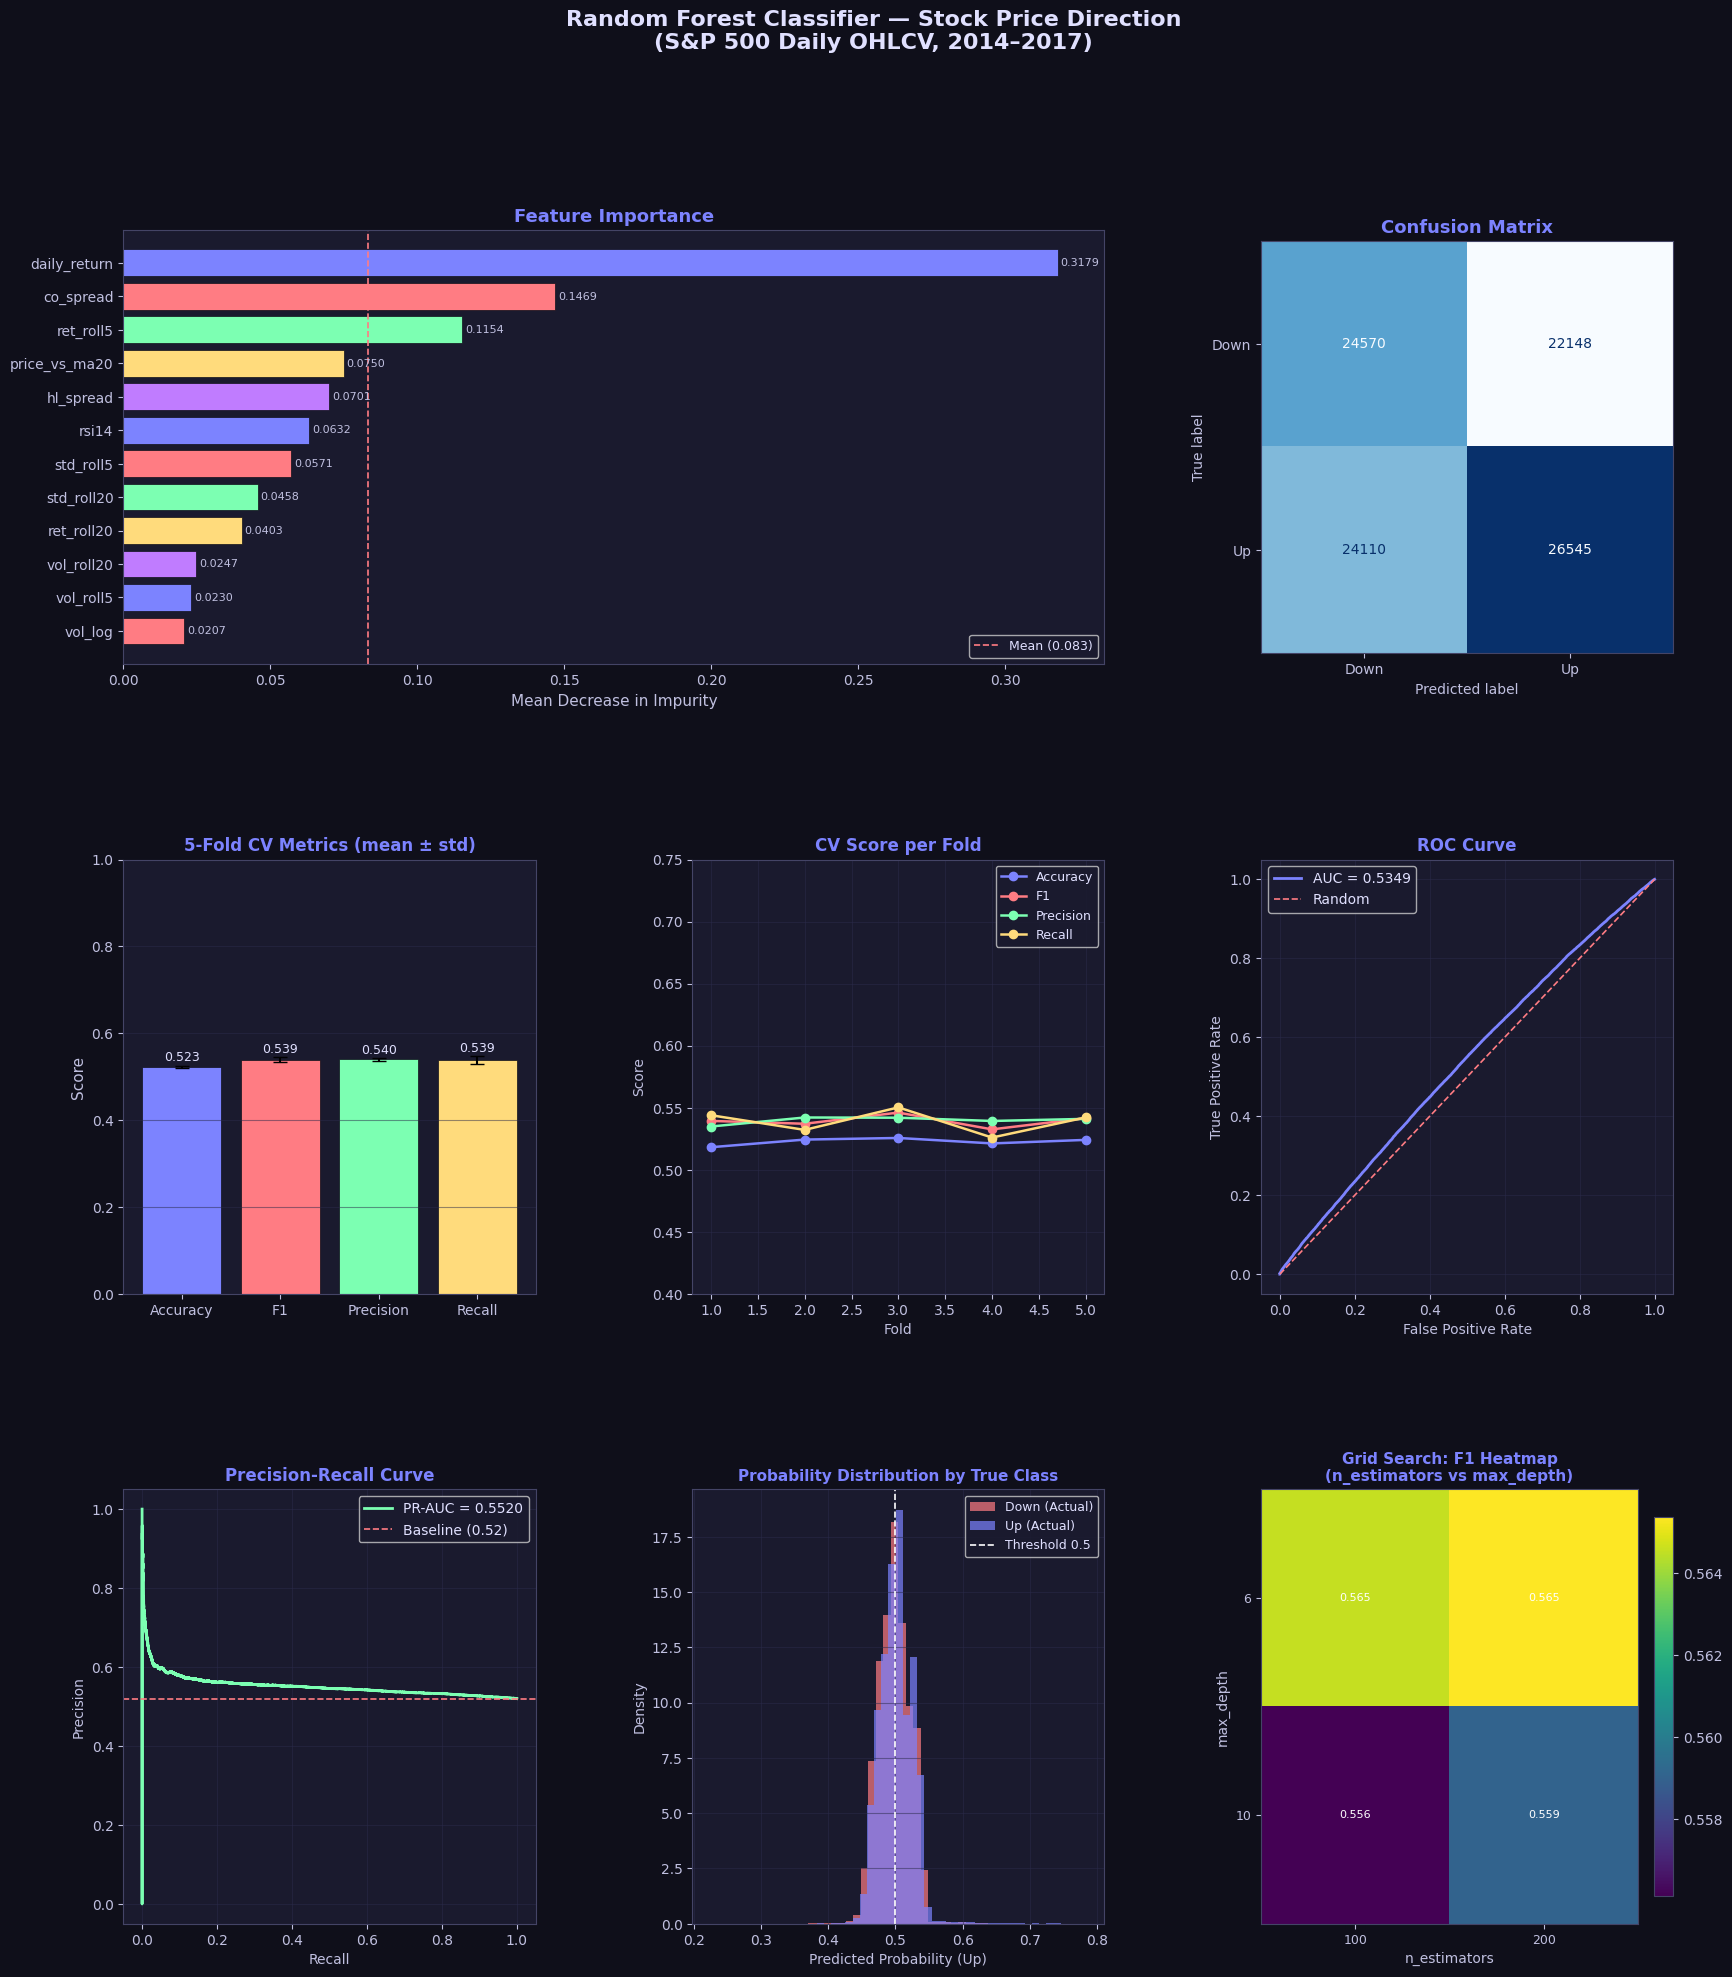

In [10]:
print("\n" + "=" * 60)
print("7. Generating Visualizations")
print("=" * 60)

fig = plt.figure(figsize=(20, 22), facecolor="#0f0f1a")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle("Random Forest Classifier — Stock Price Direction\n(S&P 500 Daily OHLCV, 2014–2017)",
             fontsize=16, fontweight="bold", color="#e0e0ff", y=0.98)

# ── Plot 1: Feature Importances ───────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors = [PALETTE[i % len(PALETTE)] for i in range(len(importance_df))]
bars = ax1.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1],
                color=colors[::-1], edgecolor="#0f0f1a", linewidth=0.5)
ax1.set_xlabel("Mean Decrease in Impurity", fontsize=11)
ax1.set_title("Feature Importance", fontsize=13, fontweight="bold", color=ACCENT)
ax1.axvline(importance_df["Importance"].mean(), color=ACCENT2, linestyle="--",
            linewidth=1.2, label=f"Mean ({importance_df['Importance'].mean():.3f})")
ax1.legend(fontsize=9)
for bar, val in zip(bars, importance_df["Importance"][::-1]):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", fontsize=8, color="#c0c0e0")

# ── Plot 2: Confusion Matrix ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
cm  = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"])
cmd.plot(ax=ax2, colorbar=False, cmap="Blues")
ax2.set_title("Confusion Matrix", fontsize=13, fontweight="bold", color=ACCENT)
ax2.set_facecolor("#1a1a2e")

# ── Plot 3: Cross-Validation Scores ──────────────────────
ax3 = fig.add_subplot(gs[1, 0])
metrics   = ["Accuracy", "F1", "Precision", "Recall"]
means     = [cv_df[m].mean() for m in metrics]
stds      = [cv_df[m].std()  for m in metrics]
x_pos     = np.arange(len(metrics))
ax3.bar(x_pos, means, yerr=stds, color=PALETTE[:4], edgecolor="#0f0f1a",
        capsize=5, linewidth=0.5)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics, fontsize=10)
ax3.set_ylim(0, 1)
ax3.set_ylabel("Score", fontsize=11)
ax3.set_title("5-Fold CV Metrics (mean ± std)", fontsize=12, fontweight="bold", color=ACCENT)
ax3.grid(axis="y")
for i, (m, s) in enumerate(zip(means, stds)):
    ax3.text(i, m + s + 0.01, f"{m:.3f}", ha="center", fontsize=9, color="#e0e0ff")

# ── Plot 4: CV scores per fold ────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
for i, metric in enumerate(metrics):
    ax4.plot(cv_df["Fold"], cv_df[metric], marker="o", label=metric,
             color=PALETTE[i], linewidth=1.8)
ax4.set_xlabel("Fold")
ax4.set_ylabel("Score")
ax4.set_title("CV Score per Fold", fontsize=12, fontweight="bold", color=ACCENT)
ax4.legend(fontsize=9)
ax4.set_ylim(0.4, 0.75)
ax4.grid()

# ── Plot 5: ROC Curve ─────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = auc(fpr, tpr)
ax5.plot(fpr, tpr, color=ACCENT, linewidth=2, label=f"AUC = {roc_auc:.4f}")
ax5.plot([0, 1], [0, 1], color=ACCENT2, linestyle="--", linewidth=1.2, label="Random")
ax5.set_xlabel("False Positive Rate")
ax5.set_ylabel("True Positive Rate")
ax5.set_title("ROC Curve", fontsize=12, fontweight="bold", color=ACCENT)
ax5.legend(fontsize=10)
ax5.grid()

# ── Plot 6: Precision-Recall Curve ───────────────────────
ax6 = fig.add_subplot(gs[2, 0])
prec, rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)
ax6.plot(rec, prec, color=ACCENT3, linewidth=2, label=f"PR-AUC = {pr_auc:.4f}")
ax6.axhline(y_test.mean(), color=ACCENT2, linestyle="--", linewidth=1.2,
            label=f"Baseline ({y_test.mean():.2f})")
ax6.set_xlabel("Recall")
ax6.set_ylabel("Precision")
ax6.set_title("Precision-Recall Curve", fontsize=12, fontweight="bold", color=ACCENT)
ax6.legend(fontsize=10)
ax6.grid()

# ── Plot 7: Prediction Probability Distribution ───────────
ax7 = fig.add_subplot(gs[2, 1])
ax7.hist(y_proba[y_test == 0], bins=50, alpha=0.7, color=ACCENT2, label="Down (Actual)", density=True)
ax7.hist(y_proba[y_test == 1], bins=50, alpha=0.7, color=ACCENT,  label="Up (Actual)",   density=True)
ax7.axvline(0.5, color="white", linestyle="--", linewidth=1.2, label="Threshold 0.5")
ax7.set_xlabel("Predicted Probability (Up)")
ax7.set_ylabel("Density")
ax7.set_title("Probability Distribution by True Class", fontsize=11, fontweight="bold", color=ACCENT)
ax7.legend(fontsize=9)
ax7.grid()

# ── Plot 8: Hyperparameter Search — n_estimators vs max_depth ──
ax8 = fig.add_subplot(gs[2, 2])
cv_res_df = pd.DataFrame(grid_search.cv_results_)
pivot_data = cv_res_df.pivot_table(
    index="param_max_depth", columns="param_n_estimators",
    values="mean_test_score", aggfunc="max"
)
im = ax8.imshow(pivot_data.values, cmap="viridis", aspect="auto")
ax8.set_xticks(range(len(pivot_data.columns)))
ax8.set_xticklabels(pivot_data.columns, fontsize=9)
ax8.set_yticks(range(len(pivot_data.index)))
ax8.set_yticklabels([str(v) for v in pivot_data.index], fontsize=9)
ax8.set_xlabel("n_estimators")
ax8.set_ylabel("max_depth")
ax8.set_title("Grid Search: F1 Heatmap\n(n_estimators vs max_depth)", fontsize=11, fontweight="bold", color=ACCENT)
plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)
for i in range(len(pivot_data.index)):
    for j in range(len(pivot_data.columns)):
        ax8.text(j, i, f"{pivot_data.values[i,j]:.3f}",
                 ha="center", va="center", fontsize=8, color="white")



## 9. SUMMARY

In [11]:
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Best hyperparameters : {best_params}")
print(f"Test ROC-AUC         : {roc_auc:.4f}")
print(f"Test PR-AUC          : {pr_auc:.4f}")
print(f"Top feature          : {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
print("Done ✓")


SUMMARY
Best hyperparameters : {'max_depth': 6, 'max_features': 0.5, 'min_samples_split': 20, 'n_estimators': 200}
Test ROC-AUC         : 0.5349
Test PR-AUC          : 0.5520
Top feature          : daily_return (0.3179)
Done ✓
